## Setup

First, let's import the required libraries:

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lorenz_phase_space.phase_diagrams import Visualizer

# Set display options
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

## 1. Creating Synthetic Data

For demonstration purposes, let's create synthetic data that mimics a cyclone lifecycle:

In [2]:
# Create synthetic cyclone data
np.random.seed(42)
n_points = 15

# Time evolution
t = np.linspace(0, 2*np.pi, n_points)

# Energy conversions (W m^-2)
Ck = 20 * np.sin(t) + 5 * np.random.randn(n_points)  # Conversion: mean to eddy KE
Ca = 15 * np.cos(t) + 3 * np.random.randn(n_points)  # Conversion: mean to eddy APE
Ge = 10 * np.sin(t + np.pi/4) + 2 * np.random.randn(n_points)  # Generation of eddy APE

# Energy reservoir (J m^-2)
Ke = 3e5 + 2e5 * np.sin(t - np.pi/3) + 0.5e5 * np.random.randn(n_points)  # Eddy KE

# Create DataFrame
data = pd.DataFrame({
    'Ck': Ck,
    'Ca': Ca,
    'Ge': Ge,
    'Ke': Ke
})

print("Sample data created:")
print(data.head())
print(f"\nData shape: {data.shape}")

Sample data created:
          Ck         Ca         Ge             Ke
0   2.483571  13.313137   5.867655   90802.708823
1   7.986353  10.476040  13.143390  164304.049839
2  18.875072  10.295089   9.910128  323047.658076
3  27.113708   0.613742   6.351820  376131.949361
4  18.327791  -7.574725   6.965411  347882.539786

Data shape: (15, 4)


## 2. Basic Mixed LPS Plot

The **mixed LPS** shows both baroclinic and barotropic instabilities:

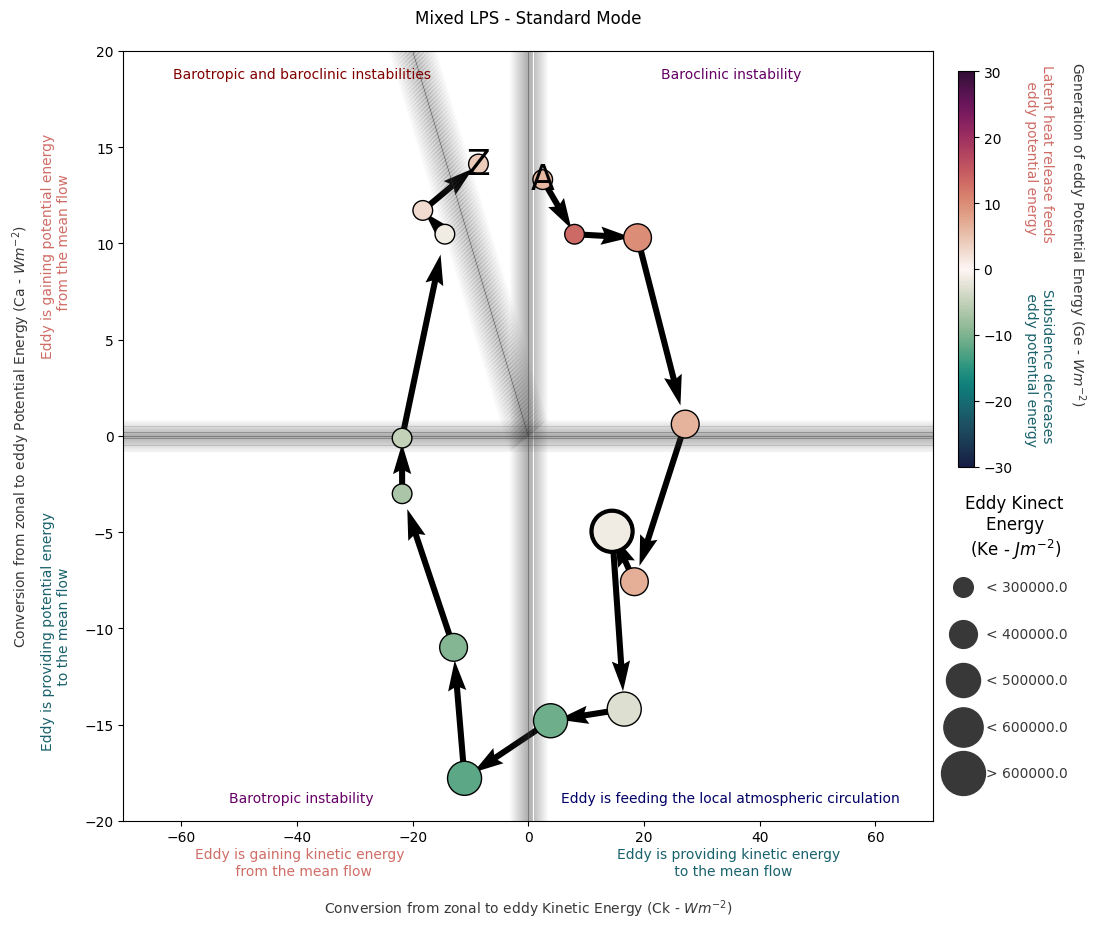

In [3]:
# Create Mixed LPS without zoom (standard mode)
lps = Visualizer(LPS_type='mixed', zoom=False)

# Plot the data
lps.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke']
)

plt.title('Mixed LPS - Standard Mode', pad=20)
plt.show()

### Interpretation

- **Upper-right quadrant**: Baroclinic instability (Ca+ and Ck+)
- **Upper-left quadrant**: Both baroclinic and barotropic instabilities
- **Lower-left quadrant**: Barotropic instability
- **Lower-right quadrant**: Eddy feeding local circulation
- **Red colors**: Latent heat release (positive Ge)
- **Blue colors**: Subsidence (negative Ge)
- **Marker 'A'**: Start of lifecycle
- **Marker 'Z'**: End of lifecycle

## 3. Zoomed LPS Plot

For detailed analysis, use **zoom mode** which adjusts limits to your data:

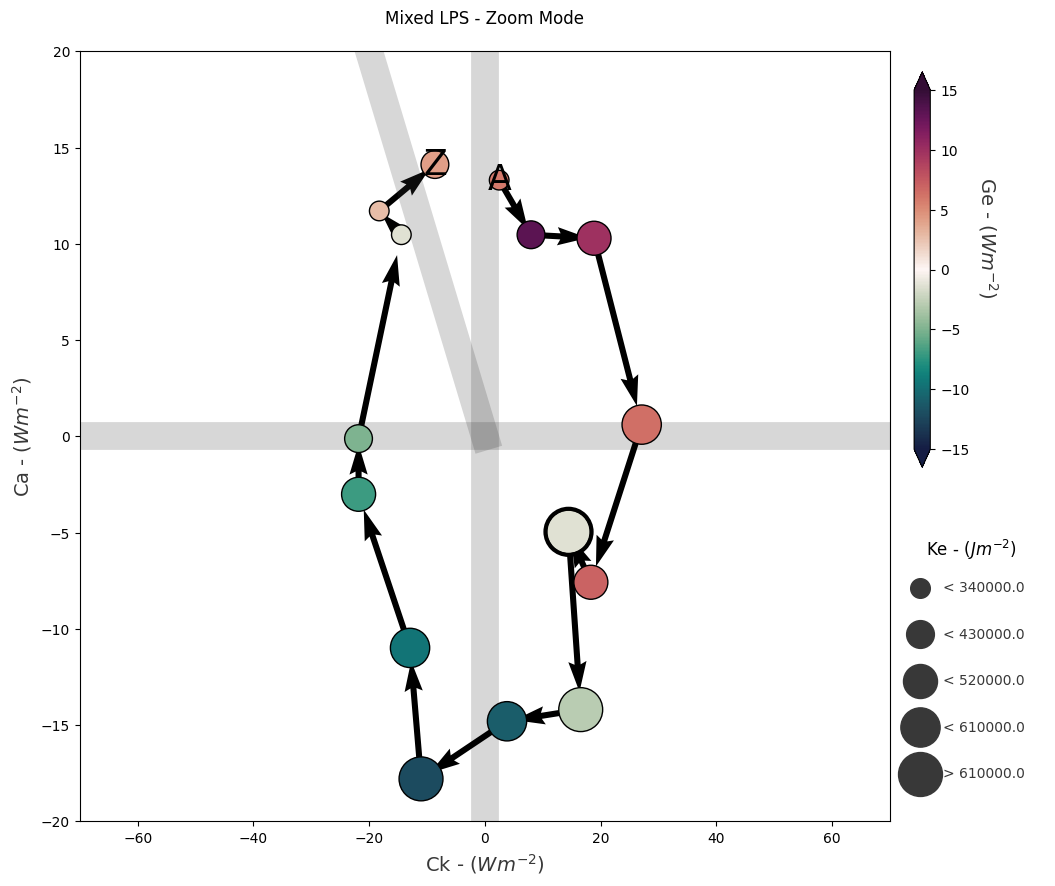

In [4]:
# Create Mixed LPS with zoom (dynamic limits)
lps_zoom = Visualizer(LPS_type='mixed', zoom=True)

# Plot the data
lps_zoom.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke']
)

plt.title('Mixed LPS - Zoom Mode', pad=20)
plt.show()

## 4. Comparing Multiple Cyclones

Let's create two cyclone datasets and compare them:

In [5]:
# Create second cyclone dataset (stronger system)
np.random.seed(24)
t2 = np.linspace(0, 2*np.pi, n_points)

data2 = pd.DataFrame({
    'Ck': 30 * np.sin(t2 + np.pi/6) + 7 * np.random.randn(n_points),
    'Ca': 25 * np.cos(t2 - np.pi/4) + 5 * np.random.randn(n_points),
    'Ge': 15 * np.sin(t2) + 3 * np.random.randn(n_points),
    'Ke': 4e5 + 2.5e5 * np.sin(t2) + 0.7e5 * np.random.randn(n_points)
})

print("Two datasets ready for comparison")
print(f"Cyclone 1 - Ck range: [{data['Ck'].min():.1f}, {data['Ck'].max():.1f}]")
print(f"Cyclone 2 - Ck range: [{data2['Ck'].min():.1f}, {data2['Ck'].max():.1f}]")

Two datasets ready for comparison
Cyclone 1 - Ck range: [-21.8, 27.1]
Cyclone 2 - Ck range: [-36.2, 27.5]


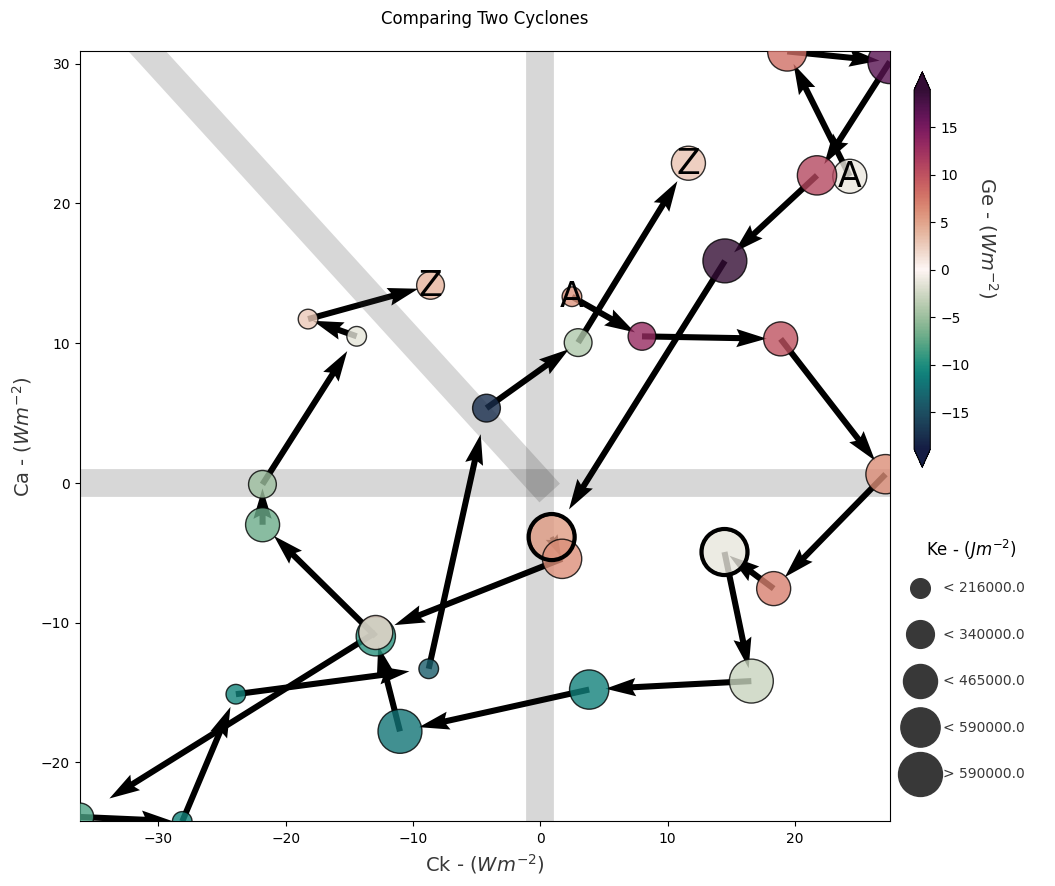

In [6]:
# Calculate common limits for fair comparison
x_min = min(data['Ck'].min(), data2['Ck'].min())
x_max = max(data['Ck'].max(), data2['Ck'].max())
y_min = min(data['Ca'].min(), data2['Ca'].min())
y_max = max(data['Ca'].max(), data2['Ca'].max())
color_min = min(data['Ge'].min(), data2['Ge'].min())
color_max = max(data['Ge'].max(), data2['Ge'].max())
size_min = min(data['Ke'].min(), data2['Ke'].min())
size_max = max(data['Ke'].max(), data2['Ke'].max())

# Create LPS with custom limits
lps_compare = Visualizer(
    LPS_type='mixed',
    zoom=True,
    x_limits=[x_min, x_max],
    y_limits=[y_min, y_max],
    color_limits=[color_min, color_max],
    marker_limits=[size_min, size_max]
)

# Plot both cyclones
lps_compare.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke'],
    alpha=0.8
)

lps_compare.plot_data(
    x_axis=data2['Ck'],
    y_axis=data2['Ca'],
    marker_color=data2['Ge'],
    marker_size=data2['Ke'],
    alpha=0.8
)

plt.title('Comparing Two Cyclones', pad=20)
plt.show()

## 5. Baroclinic LPS

Focus specifically on **baroclinic processes**:

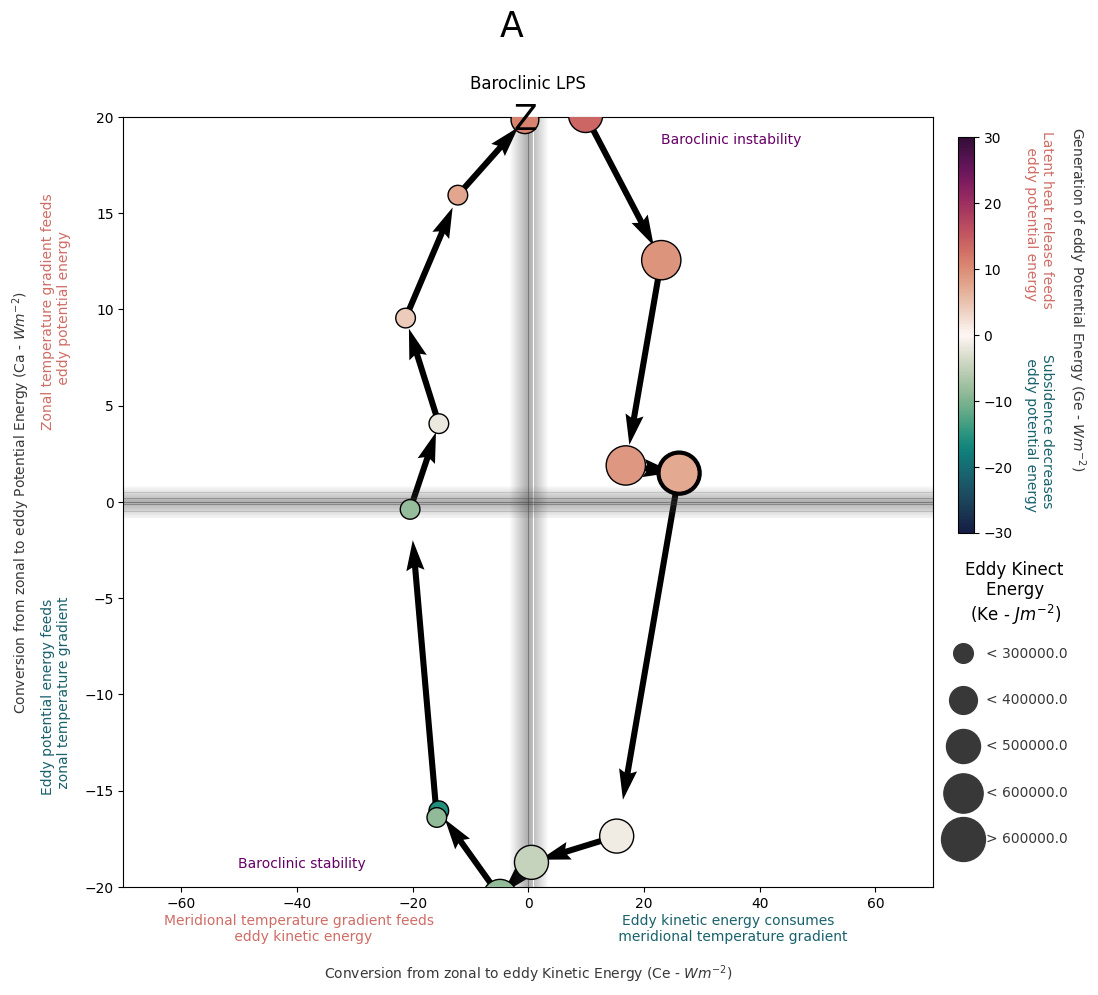

In [7]:
# Create baroclinic-specific data
data_baro = pd.DataFrame({
    'Ce': 25 * np.sin(t) + 4 * np.random.randn(n_points),  # Zonal to eddy KE conversion
    'Ca': 20 * np.cos(t) + 3 * np.random.randn(n_points),  # Zonal to eddy APE conversion
    'Ge': 12 * np.sin(t + np.pi/3) + 2 * np.random.randn(n_points),
    'Ke': 3.5e5 + 2e5 * np.sin(t) + 0.5e5 * np.random.randn(n_points)
})

# Create Baroclinic LPS
lps_baro = Visualizer(LPS_type='baroclinic', zoom=False)

lps_baro.plot_data(
    x_axis=data_baro['Ce'],
    y_axis=data_baro['Ca'],
    marker_color=data_baro['Ge'],
    marker_size=data_baro['Ke']
)

plt.title('Baroclinic LPS', pad=20)
plt.show()

## 6. Imports LPS

Analyze **energy imports and exports** across boundaries:

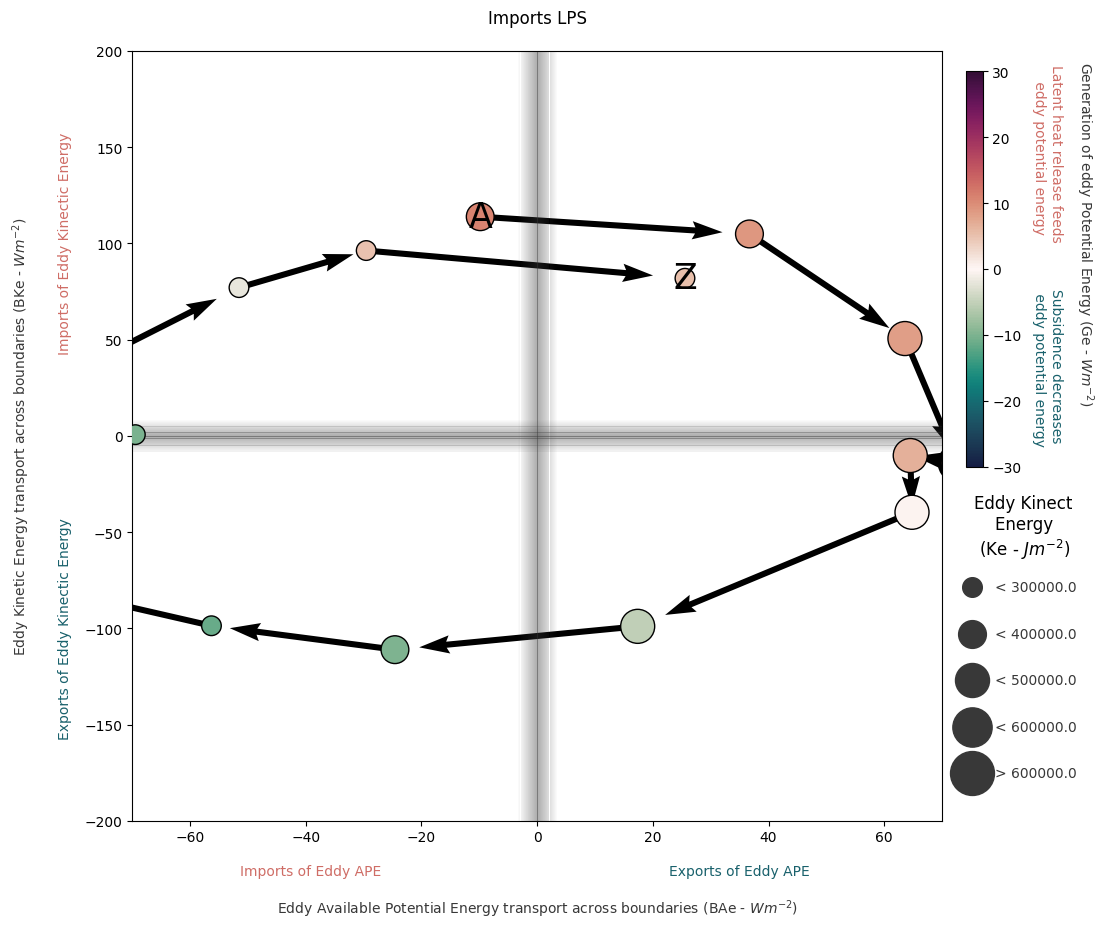

In [8]:
# Create imports/exports data
data_imports = pd.DataFrame({
    'BAe': 80 * np.sin(t) + 15 * np.random.randn(n_points),  # Eddy APE transport
    'BKe': 100 * np.cos(t) + 20 * np.random.randn(n_points),  # Eddy KE transport
    'Ge': 10 * np.sin(t + np.pi/4) + 2 * np.random.randn(n_points),
    'Ke': 3e5 + 2e5 * np.sin(t) + 0.5e5 * np.random.randn(n_points)
})

# Create Imports LPS
lps_imports = Visualizer(LPS_type='imports', zoom=False)

lps_imports.plot_data(
    x_axis=data_imports['BAe'],
    y_axis=data_imports['BKe'],
    marker_color=data_imports['Ge'],
    marker_size=data_imports['Ke']
)

plt.title('Imports LPS', pad=20)
plt.show()

## 7. Working with Real Data

If you have real cyclone data in a CSV file:

In [9]:
# Example of loading real data
# Uncomment and modify the path to use your own data

# real_data = pd.read_csv('path/to/your/cyclone_data.csv', 
#                         parse_dates={'Datetime': ['Date', 'Hour']},
#                         date_format='%Y-%m-%d %H')

# Check required columns
# required_columns = ['Ck', 'Ca', 'Ge', 'Ke']
# print("Available columns:", real_data.columns.tolist())
# print("Has required columns:", all(col in real_data.columns for col in required_columns))

# Create and plot
# lps_real = Visualizer(LPS_type='mixed', zoom=True)
# lps_real.plot_data(
#     x_axis=real_data['Ck'],
#     y_axis=real_data['Ca'],
#     marker_color=real_data['Ge'],
#     marker_size=real_data['Ke']
# )
# plt.title('Real Cyclone Data', pad=20)
# plt.show()

print("To use real data, uncomment the code above and provide your CSV file path.")

To use real data, uncomment the code above and provide your CSV file path.


## 8. Saving Figures

Save publication-quality figures:

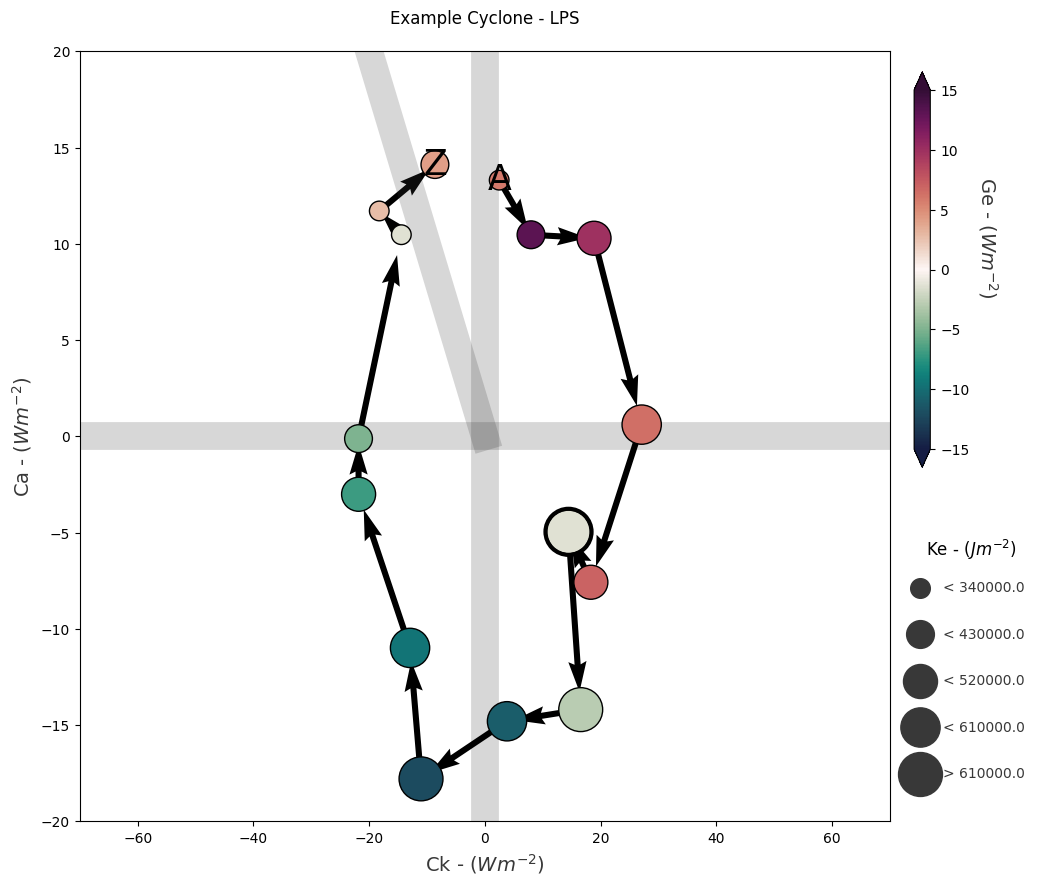


To save figures, uncomment the plt.savefig() lines above.


In [10]:
# Create a figure to save
lps_save = Visualizer(LPS_type='mixed', zoom=True)
lps_save.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke']
)

plt.title('Example Cyclone - LPS', pad=20)

# Save in multiple formats
# plt.savefig('lps_diagram.png', dpi=300, bbox_inches='tight')
# plt.savefig('lps_diagram.pdf', bbox_inches='tight')
# plt.savefig('lps_diagram.svg', bbox_inches='tight')

plt.show()
print("\nTo save figures, uncomment the plt.savefig() lines above.")

## Summary

This notebook demonstrated:

1. ✅ Creating basic Mixed LPS plots
2. ✅ Using zoom mode for detailed analysis
3. ✅ Comparing multiple cyclones with custom limits
4. ✅ Creating Baroclinic LPS plots
5. ✅ Creating Imports LPS plots
6. ✅ Guidelines for working with real data
7. ✅ Saving publication-quality figures

## Next Steps

- Review the [API Documentation](../docs/API_DOCUMENTATION.md) for detailed parameter descriptions
- Check the [Quick Reference](../docs/QUICK_REFERENCE.md) for common use cases
- Read the [Testing Guide](../tests/TESTING.md) to understand the test suite

## References

- Hart, R. E. (2003). A Cyclone Phase Space derived from thermal wind and thermal asymmetry. *Monthly Weather Review*, 131(4), 585-616.
- Lorenz, E. N. (1955). Available potential energy and the maintenance of the general circulation. *Tellus*, 7(2), 157-167.